# Flutter

In [1]:
import numpy as np
import control as c
import control.matlab as ml
import seaborn as sns

## Inputs

In [24]:
massAC = 1200
V = 77
rhoair = 0.962870
b = 11.4
MAC = 0.5
massperlength = 25 # kg/m
cog = 0.5 # chords
EI = 7e5 # Nm^2
GJ = 2e5 # Nm^2
ac = 0.25 # chords
Cla = 2 * np.pi
engineMass = 30 # kg
Cma = -0.1
z = b
wingboxb, wingboxh = 0.6, 0.3
S1 = 5.5
distanceT = 0.2 # Distance from engine to center in chords
u = 15 # gust velocity [m/s]

$T = \frac{G J}{L} \theta$

$k_h = \frac{C_1 \cdot E I}{L^3} \qquad k_\alpha = \frac{G J}{L}$

Radius of gyration: $\rho = \sqrt{\frac{I}{m}} = \sqrt{\frac{\text{base} \times \text{height}}{6}}$

<AxesSubplot:>

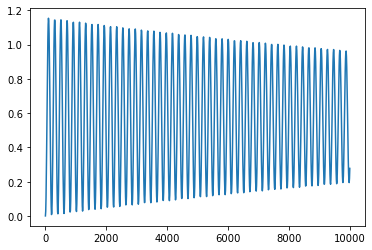

In [25]:
steps = 1000
q = 0.5 * rhoair * V ** 2
cg = cog * MAC
C1 = 3 # Fixed support
M = massperlength * z
S = S1 / 2 # Half wing area
Iz = (M / 6) * wingboxb * wingboxh # https://www.piping-designer.com/index.php/mathematics/geometry/plane-geometry/2342-thin-wall-rectangle
ka, kh = 2 * GJ / z, C1 * EI / (z / 2) ** 3
Dh = 0.0035 / 0.15 # https://www.sciencedirect.com/science/article/pii/S1877705816302284
Da = Dh * np.sqrt(kh * Iz) / np.sqrt(ka * M) # Keeping the critical damping ratio the same
dT = distanceT * MAC
WT = engineMass * 9.81
force = np.concatenate([np.array([[(q / V) * Cla * S * u - M * 9.81 - WT, -WT * dT]]).T]*steps, axis=1)

A3 = -(1 / M) * np.array([kh, Cla * q * S, Dh, 0])
A4 = -(1 / Iz) * np.array([0, ka + Cma * q * S * MAC + Cla * q * S * (cg - ac) * MAC, 0, Da])

A = np.array([[0, 0, 1, 0], [0, 0, 0, 1], A3, A4])
B = np.concatenate([np.zeros((2, 2)), [[1 / M, 0], [0, 1 / Iz]]])
C = np.concatenate([np.identity(4), A[-2:, :]])
D = np.concatenate([np.zeros((4, 2)), [[1 / M, 0], [0, 1 / Iz]]])

sys = ml.ss(A, B, C, D)
T = np.linspace(0, 10000, steps)
T, y = c.forced_response(sys, T, U=force)
sns.lineplot(x=T, y=y[0, :])